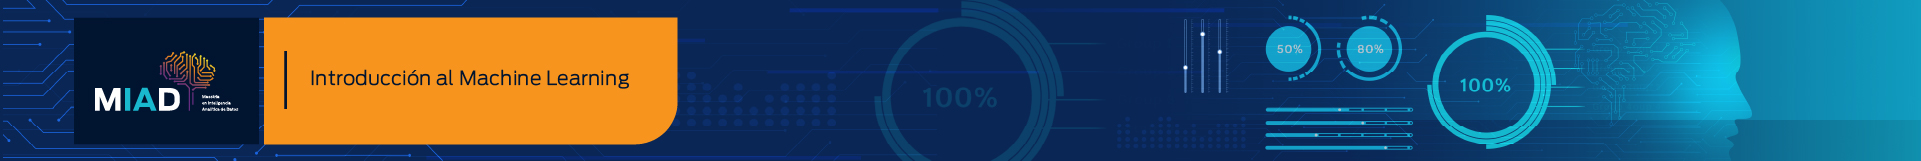

# Introducción al Machine Learning - Semana 6
## Caso: implementación de metodologías de imputación de variables e imbalanceo de clases


### Propósito de la actividad

En esta actividad podrán poner en práctica, con un conjunto de datos reales, su habilidad para gestionar situaciones de datos faltantes e imbalanceo de clases.

Además, como en todo procedimiento de analítica de datos, se evaluará la exploración preliminar de los datos por medio de herramientas como histogramas, correlogramas y estadísticas descriptivas.

### Instrucciones generales

1. Para desarrollar el notebook, lo deberán descargar a un repositorio (pueden escoger el repositorio de su preferencia) para que lo puedan trabajar grupalmente.

2. Los procedimientos en el notebook deberán responderse en los espacios especificados para tal fin, debajo de cada uno de los puntos.

3. Para que la actividad sea calificada, deberán subir únicamente este mismo archivo con la extensión ".ipynb" a la actividad de "entrega calificada por el personal" correspondiente a este caso.

4. El archivo que suban debe poder ejecutarse localmente cuando sea descargado por el tutor, asumiendo que la base de datos de la actividad ya ha sido importada en el correspondiente archivo separado por comas (.csv).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn import metrics
from sklearn.metrics import precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve

### Primer conjunto de datos

Utilice el archivo de datos "Missing data.csv" que se encuentra en este repositorio para hacer los siguientes tres puntos:

### 1. Análisis preliminar de variables del primer conjunto de datos (5 puntos)

Realicen un análisis preliminar de los predictores y de la variable de respuesta para el primer conjunto de datos (correlogramas, histogramas y estadísticas descriptivas).

In [2]:
# carga de datos
df = pd.read_csv('MissingData.csv')

XTotal = df.loc[:, df.columns != "Class"]
yTotal = df.loc[:, df.columns == "Class"]

print(df.shape)
print(df.head())


(683, 36)
                   Class  date  plant.stand  precip  temp  hail  crop.hist  \
0  diaporthe-stem-canker   6.0          0.0     2.0   1.0   0.0        1.0   
1  diaporthe-stem-canker   4.0          0.0     2.0   1.0   0.0        2.0   
2  diaporthe-stem-canker   3.0          0.0     2.0   1.0   0.0        1.0   
3  diaporthe-stem-canker   3.0          0.0     2.0   1.0   0.0        1.0   
4  diaporthe-stem-canker   6.0          0.0     2.0   1.0   0.0        2.0   

   area.dam  sever  seed.tmt  ...  int.discolor  sclerotia  fruit.pods  \
0       1.0    1.0       0.0  ...           0.0        0.0         0.0   
1       0.0    2.0       1.0  ...           0.0        0.0         0.0   
2       0.0    2.0       1.0  ...           0.0        0.0         0.0   
3       0.0    2.0       0.0  ...           0.0        0.0         0.0   
4       0.0    1.0       0.0  ...           0.0        0.0         0.0   

   fruit.spots  seed  mold.growth  seed.discolor  seed.size  shriveling  roo

inspeccion basica del dataset

In [3]:
print("Estructura del dataset:", df.shape)
display(df.head())


Estructura del dataset: (683, 36)


,Class,date,plant.stand,precip,temp,hail,crop.hist,area.dam,sever,seed.tmt,...,int.discolor,sclerotia,fruit.pods,fruit.spots,seed,mold.growth,seed.discolor,seed.size,shriveling,roots
0,diaporthe-stem-canker,6.0,0.0,2.0,1.0,0.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0
1,diaporthe-stem-canker,4.0,0.0,2.0,1.0,0.0,2.0,0.0,2.0,1.0,...,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0
2,diaporthe-stem-canker,3.0,0.0,2.0,1.0,0.0,1.0,0.0,2.0,1.0,...,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0
3,diaporthe-stem-canker,3.0,0.0,2.0,1.0,0.0,1.0,0.0,2.0,0.0,...,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0
4,diaporthe-stem-canker,6.0,0.0,2.0,1.0,0.0,2.0,0.0,1.0,0.0,...,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
print("\nEstadísticas descriptivas:")
display(XTotal.describe())



Estadísticas descriptivas:


,date,plant.stand,precip,temp,hail,crop.hist,area.dam,sever,seed.tmt,germ,...,int.discolor,sclerotia,fruit.pods,fruit.spots,seed,mold.growth,seed.discolor,seed.size,shriveling,roots
count,682.000000,647.000000,645.000000,653.000000,562.000000,667.000000,682.000000,562.000000,562.000000,571.000000,...,645.000000,645.000000,599.000000,577.000000,591.000000,591.000000,577.000000,591.000000,577.000000,652.000000
mean,3.554252,0.452859,1.596899,1.182236,0.225979,1.884558,1.580645,0.733096,0.519573,1.049037,...,0.130233,0.031008,0.504174,1.020797,0.194585,0.113367,0.110919,0.099831,0.065858,0.177914
std,1.694117,0.498158,0.686147,0.628214,0.418598,0.975766,1.074374,0.597028,0.612241,0.790988,...,0.418998,0.173473,0.882513,1.503324,0.396217,0.317310,0.314304,0.300028,0.248249,0.438826
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.000000,0.000000,2.000000,1.000000,0.000000,2.000000,1.000000,1.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,5.000000,1.000000,2.000000,2.000000,0.000000,3.000000,3.000000,1.000000,1.000000,2.000000,...,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,6.000000,1.000000,2.000000,2.000000,1.000000,3.000000,3.000000,2.000000,2.000000,2.000000,...,2.000000,1.000000,3.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000


revisemos los datos faltantes

In [5]:
# datos faltantes
missing_data = XTotal.isnull().sum()
print("\nValores faltantes detectados:")
print(missing_data[missing_data > 0])



Valores faltantes detectados:
date                 1
plant.stand         36
precip              38
temp                30
hail               121
crop.hist           16
area.dam             1
sever              121
seed.tmt           121
germ               112
plant.growth        16
leaf.halo           84
leaf.marg           84
leaf.size           84
leaf.shread        100
leaf.malf           84
leaf.mild          108
stem                16
lodging            121
stem.cankers        38
canker.lesion       38
fruiting.bodies    106
ext.decay           38
mycelium            38
int.discolor        38
sclerotia           38
fruit.pods          84
fruit.spots        106
seed                92
mold.growth         92
seed.discolor      106
seed.size           92
shriveling         106
roots               31
dtype: int64


¿como se distribuye los datos?

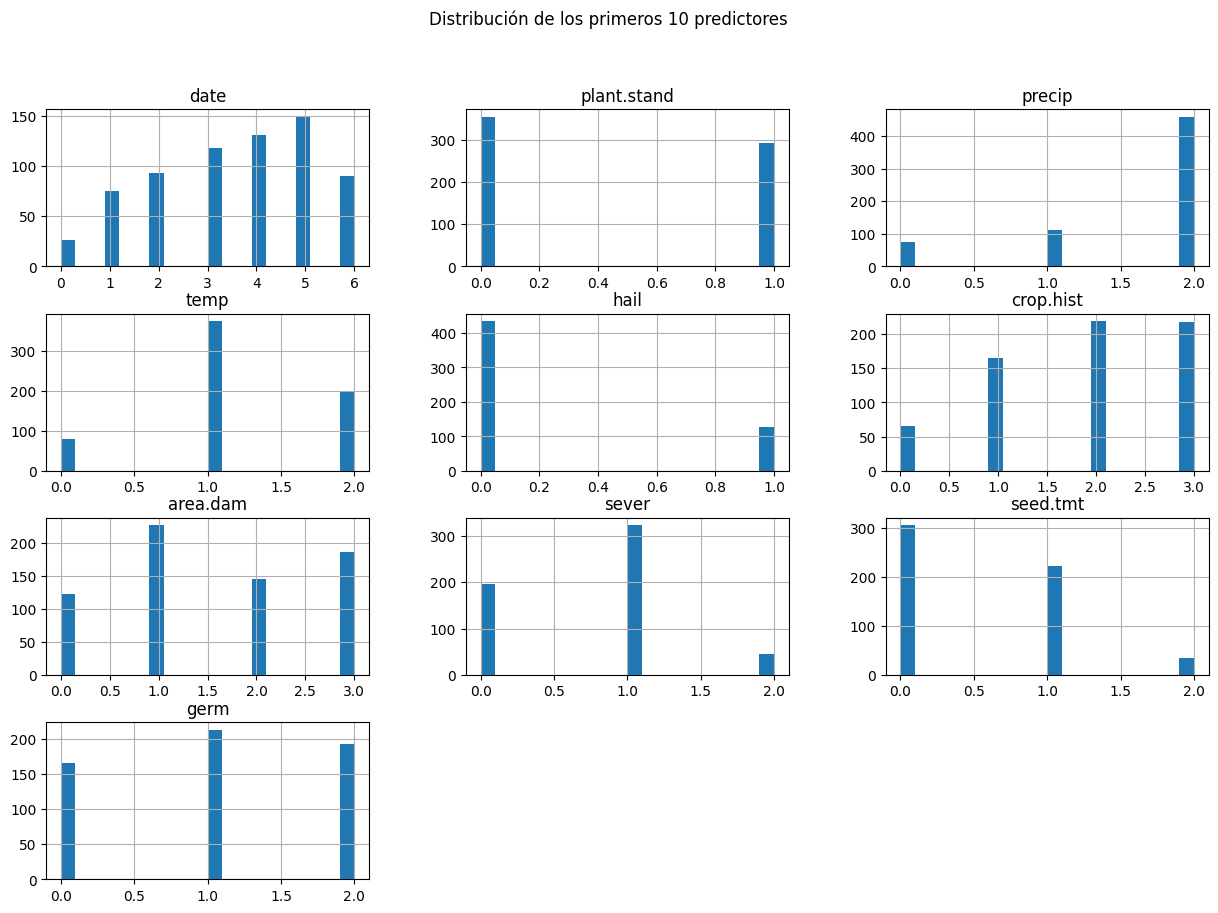

In [6]:
XTotal.iloc[:, :10].hist(bins=20, figsize=(15, 10))
plt.suptitle('Distribución de los primeros 10 predictores')
plt.show()


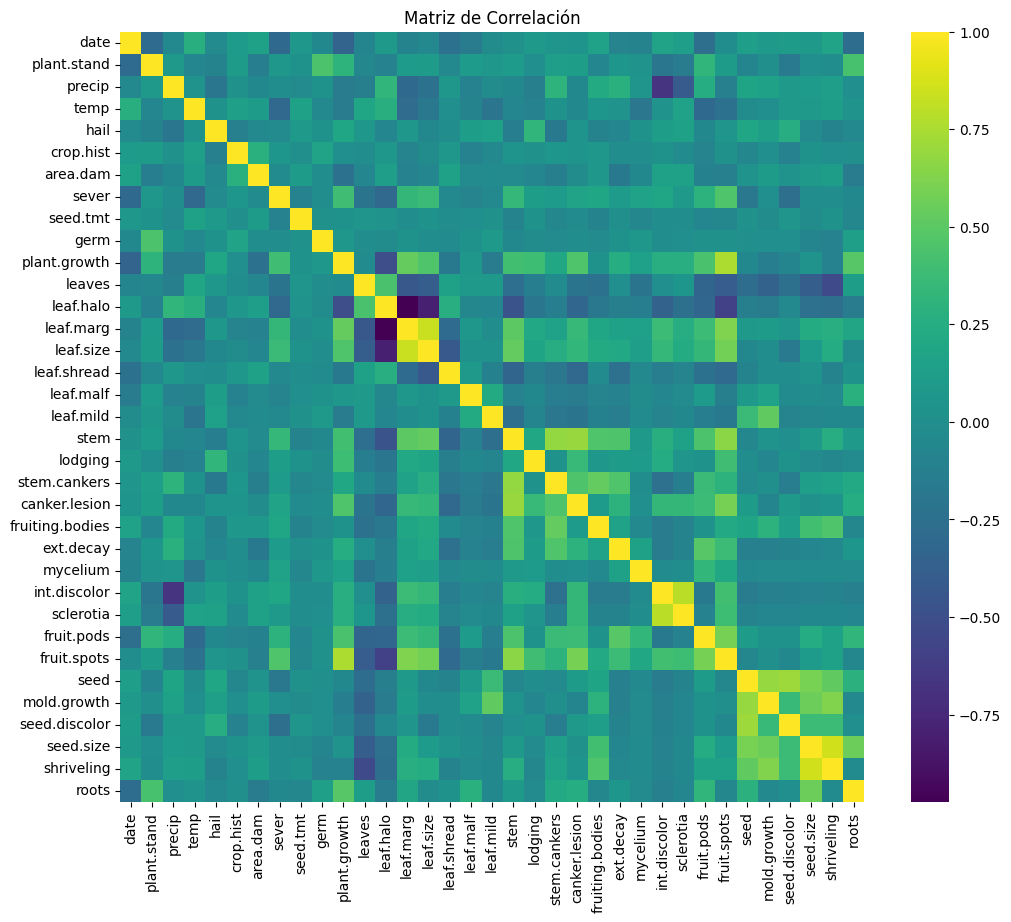

In [7]:
plt.figure(figsize=(12, 10))
sns.heatmap(XTotal.corr(), annot=False, cmap='viridis')
plt.title("Matriz de Correlación")
plt.show()



Distribución de la clase objetivo:


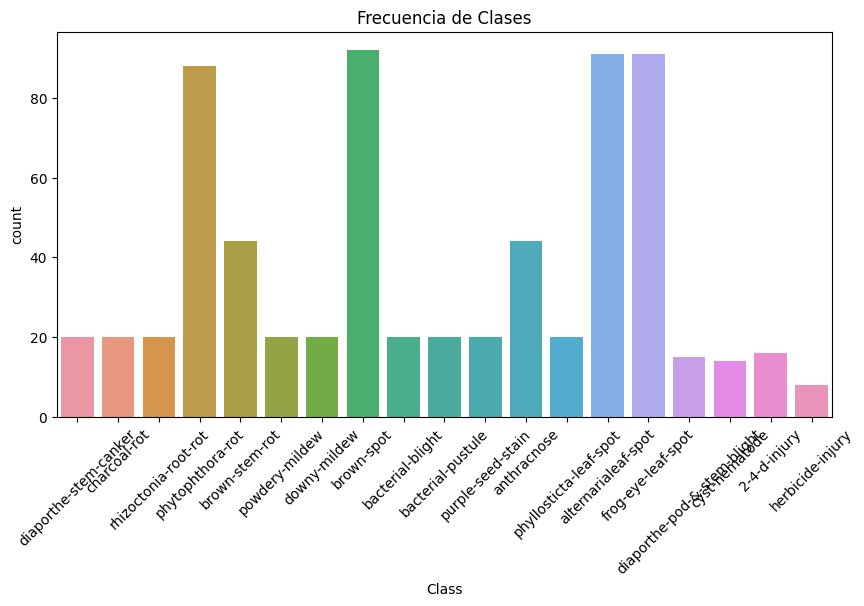

In [8]:
print("\nDistribución de la clase objetivo:")
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Class')
plt.xticks(rotation=45)
plt.title("Frecuencia de Clases")
plt.show()


#### Análisis y Conclusión Punto 1

* El conjunto de datos contiene 36 características (predictores) y una variable de respuesta ('class').
* Se observa la presencia de valores faltantes, los cuales deben ser gestionados posteriormente.
* La matriz de correlación indica relaciones variadas entre los predictores.
* Existe un desbalance notable en la distribución de las clases, lo que anticipa la necesidad de técnicas de balanceo si este fuera el objetivo final del modelo predictivo.

### 2. Gestión de datos faltantes (25 puntos)
Realicen una partición de la muestra en un conjunto de entrenamiento y otro de evaluación. Con la muestra de entrenamiento, realicen un procedimiento de imputación simple multivariada para todas las variables que tengan datos faltantes en sus filas.

In [9]:
# particion de la muestra
X = XTotal.copy()
y = yTotal['Class'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# imputacion multivariada con IterativeImputer
# Este metodo utiliza informacion de multiples variables para reemplazar las observaciones faltantes
imp_multi = IterativeImputer(max_iter=10, random_state=0)
imp_multi.fit(X_train)

# transformar train y test
X_train_imputado = pd.DataFrame(imp_multi.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imputado = pd.DataFrame(imp_multi.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Datos faltantes en X_train tras imputación multivariada:", X_train_imputado.isnull().sum().sum())
print("Datos faltantes en X_test tras imputación multivariada:", X_test_imputado.isnull().sum().sum())
display(X_train_imputado.head())


Datos faltantes en X_train tras imputación multivariada: 0
Datos faltantes en X_test tras imputación multivariada: 0


C:\Users\ACER\anaconda3\lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


,date,plant.stand,precip,temp,hail,crop.hist,area.dam,sever,seed.tmt,germ,...,int.discolor,sclerotia,fruit.pods,fruit.spots,seed,mold.growth,seed.discolor,seed.size,shriveling,roots
177,3.0,0.0,2.0,1.0,1.0,3.0,3.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
457,1.0,1.0,2.0,1.0,0.0,3.0,3.0,1.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
429,1.0,1.0,2.0,1.0,0.0,3.0,2.0,1.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
83,3.0,1.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0,1.0,...,1.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0
501,5.0,0.0,2.0,2.0,1.0,2.0,2.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0


#### Análisis y Conclusión Punto 2

* Se realizó una partición de los datos en entrenamiento (70%) y evaluación (30%) utilizando `train_test_split`.
* Para la gestión de datos faltantes se implementó una **imputación multivariada** mediante `IterativeImputer` de scikit-learn, con un máximo de 10 iteraciones y semilla aleatoria fija para reproducibilidad.
* A diferencia de la imputación univariada (que usa solo la información de cada variable individual), la imputación multivariada utiliza la información de **múltiples variables simultáneamente** para estimar los valores faltantes, lo que permite capturar las relaciones entre predictores y generar imputaciones más precisas.
* El ajuste del imputador se realizó exclusivamente con el conjunto de entrenamiento (`fit` en train), y la transformación se aplicó tanto al conjunto de entrenamiento como al de evaluación, evitando así la fuga de información (*data leakage*).
* Al finalizar el proceso, ambos conjuntos de datos no presentan valores nulos, lo que habilita la aplicación de modelos de aprendizaje supervisado.

### 3. Estimación de modelo de clasificación (10 puntos)
Escojan un modelo de clasificación de los vistos en la semana 3 del curso e impleméntenlo. Evalúen su poder predictivo en la muestra de evaluación debidamente transformada, de acuerdo a la imputación hecha en el conjunto entrenamiento.

In [10]:
# inicializacion y entreno con datos imputados multivariadamente
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_imputado, y_train)

# predicciones sobre el set de evaluacion (imputado con el mismo criterio)
y_pred_3 = model.predict(X_test_imputado)


evaluacion del desempeño

In [11]:
print("Resultados del Modelo de Regresión Logística:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_3):.4f}")

Resultados del Modelo de Regresión Logística:
Accuracy: 0.9317


In [12]:
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_3))


Matriz de Confusión:
[[ 6  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 25  0  0  0  0  0  0  0  0  0  0  3  0  0  0  0  0  0]
 [ 0  0 13  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  6  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  1  7  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 20  0  0  0  0  0  0  4  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 15  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  7  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  2  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  6  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  5  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  6  0  0  0  0  0  0  0]
 [ 0  5  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  3  0  0  0  0  0]
 [ 0  0  0  0  0  1  0  0  0  0  0  0  0  0  4  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 32  0  0  0]
 [ 0  0  0  0  0  

In [13]:
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_3))


Reporte de Clasificación:
                             precision    recall  f1-score   support

               2-4-d-injury       1.00      1.00      1.00         6
        alternarialeaf-spot       0.83      0.89      0.86        28
                anthracnose       1.00      1.00      1.00        13
           bacterial-blight       0.86      1.00      0.92         6
          bacterial-pustule       1.00      0.88      0.93         8
                 brown-spot       0.95      0.83      0.89        24
             brown-stem-rot       1.00      1.00      1.00        15
               charcoal-rot       1.00      1.00      1.00         7
              cyst-nematode       1.00      1.00      1.00         2
diaporthe-pod-&-stem-blight       1.00      1.00      1.00         6
      diaporthe-stem-canker       1.00      1.00      1.00         5
               downy-mildew       1.00      1.00      1.00         6
         frog-eye-leaf-spot       0.74      0.80      0.77        25
      

#### Análisis y Conclusión Punto 3

* Se implementó un modelo de **Regresión Logística** sobre los datos imputados mediante el método multivariado.
* El modelo fue entrenado con los datos de entrenamiento imputados y evaluado sobre el conjunto de test, el cual fue transformado con el mismo imputador ajustado en entrenamiento.
* Las métricas de desempeño (accuracy, matriz de confusión y reporte de clasificación) permiten evaluar la capacidad predictiva del modelo sobre datos con valores originalmente faltantes que fueron imputados de forma coherente.
* Estas métricas servirán de punto de comparación para modelos más complejos o estrategias de balanceo posteriores.

### Segundo conjunto de datos

Para los siguientes cinco puntos, utilice la base de datos "raw_df" que tiene información sobre tarjetas de crédito y se descarga con las siguientes líneas de código:

In [14]:
raw_df = pd.read_csv('https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv')
##raw_df.head()
print(raw_df.dtypes)

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


### 4. Análisis preliminar de variables del segundo conjunto de datos (5 puntos)

Realicen un análisis preliminar de los predictores y de la variable de respuesta para el segundo conjunto de datos (correlogramas, histogramas y estadísticas descriptivas).

In [15]:
#### Utilicen este espacio para escribir los códigos del procedimiento del punto 4 ####

raw_df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


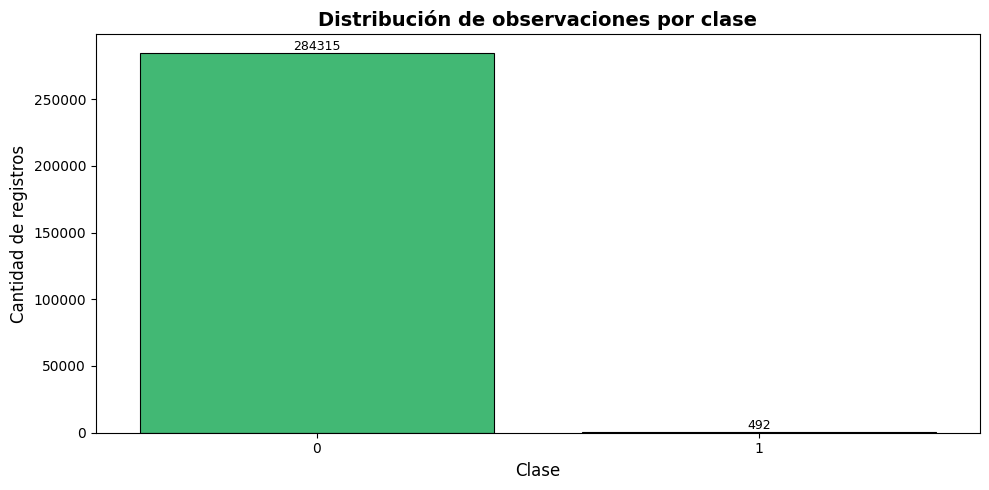

In [16]:

fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(x="Class", data=raw_df, color="#2ecc71", edgecolor="black", linewidth=0.8)
ax.set_title("Distribución de observaciones por clase", fontsize=14, fontweight="bold")
ax.set_xlabel("Clase", fontsize=12)
ax.set_ylabel("Cantidad de registros", fontsize=12)
ax.tick_params(axis="both", labelsize=10)

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,  
            height,                             
            f'{int(height)}',                   
            ha='center', va='bottom', fontsize=9
        )

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


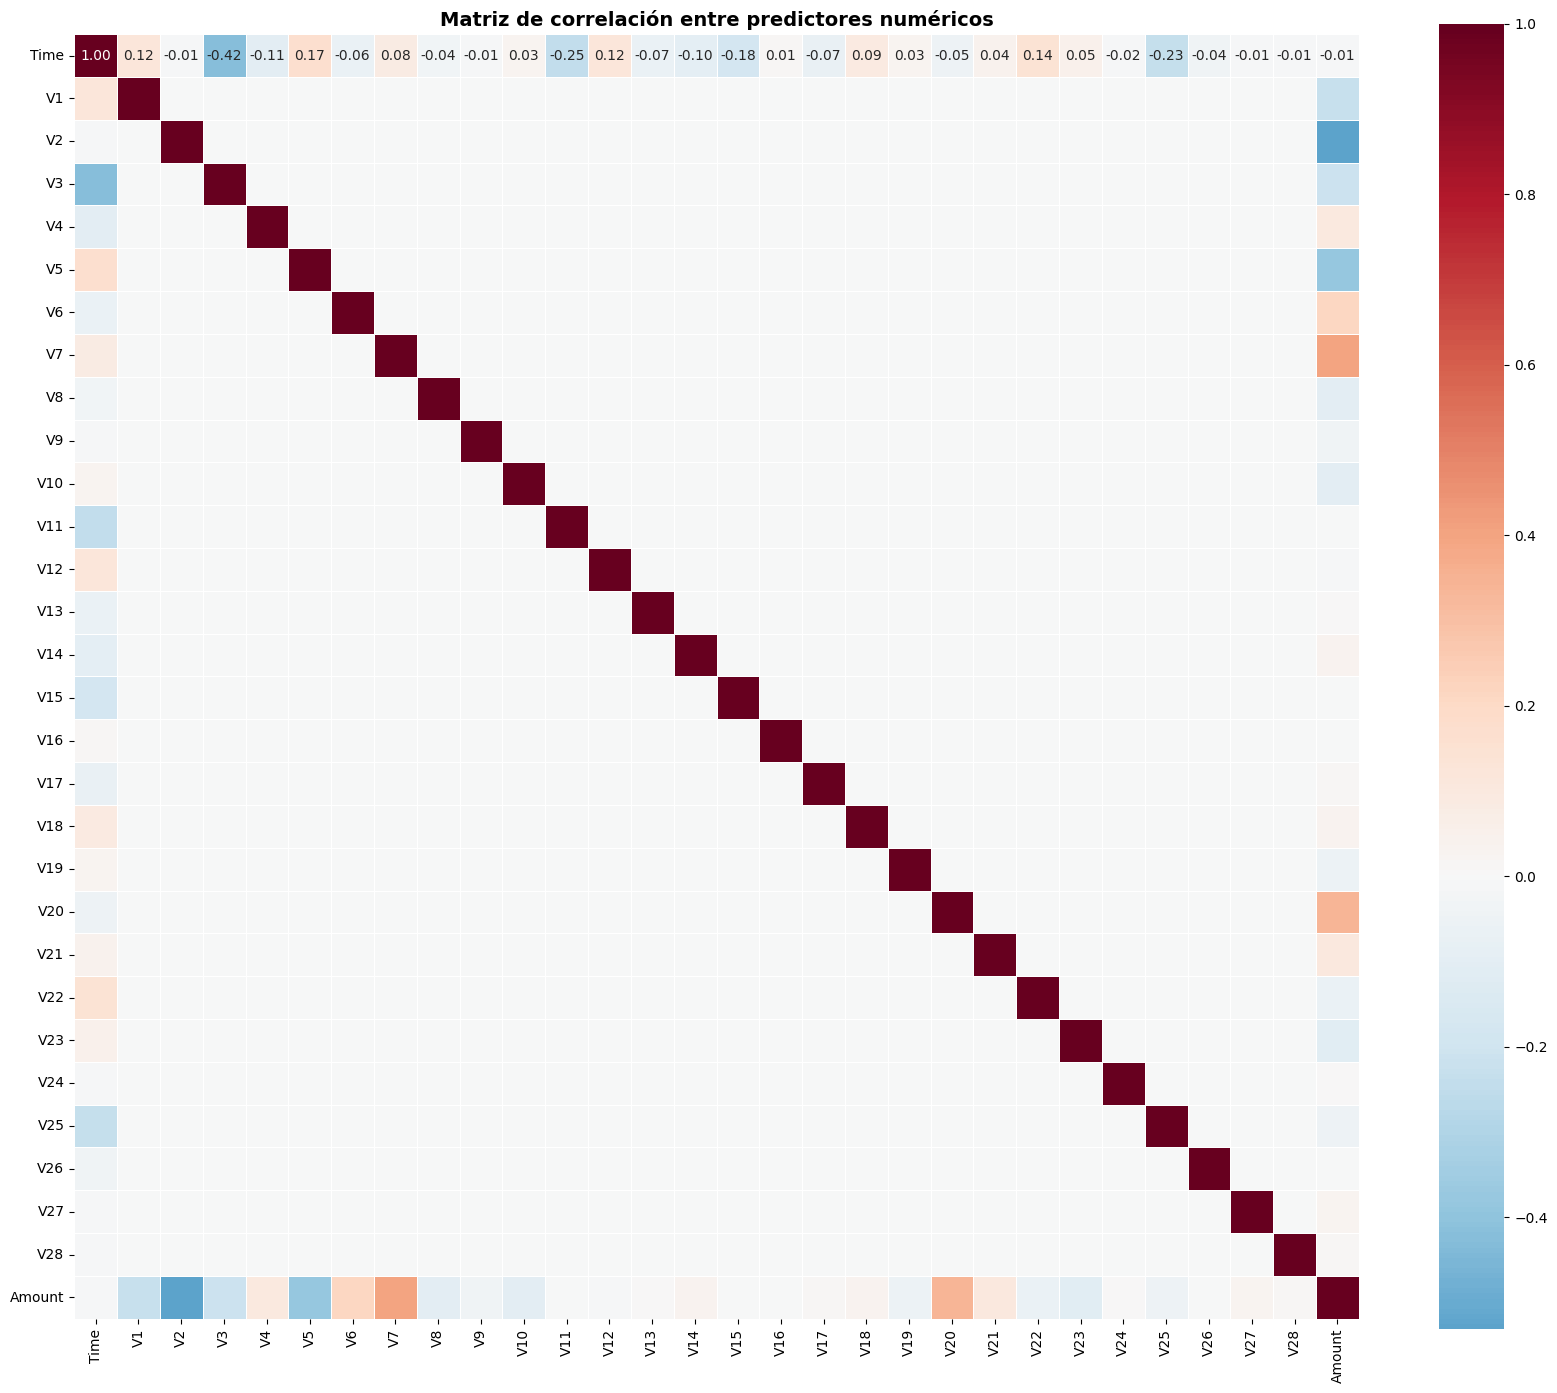

In [17]:
# Correlograma: matriz de correlación + heatmap (multicolinealidad)
cols_num = ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28','Amount']
corr_mat = raw_df[cols_num].corr()

fig, ax = plt.subplots(figsize=(17, 14))
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Matriz de correlación entre predictores numéricos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


#### Análisis y Conclusión Punto 4

Dadas las anteriores graficas, se pueden concluir las siguientes afirmaciones...
    
* Class: Con apenas 492 registros que representan la clase '0', y 284.315 de '1', se confirma que la varibale Class cuanta con desbalanceo, representando apenas u 0,17% del total de la varibale Class.
    
* Amount: tiene un promedio de 88.35 unidades monetarias, con una distribución muy sesgada, la mediana es 22, mientras que el promedio es mucho mayor, lo que indica que hay pocas transacciones de montos muy altos que elevan la media.
        
* Vtype: Se puede deducir que son varibales transformadas, con desviaciones estándar entre ~0.3 y ~2.0, y los rangos (min y max) muestran que algunas componentes tienen valores extremos (ejemplo V2 llega a -72.7 y V7 hasta 120.6).

Si la mayoría de las correlaciones son cercanas a cero (blancas), significa que las variables son relativamente independientes, lo cual suele ser bueno para modelos predictivos porque reduce la multicolinealidad.
        

### 5. Implementación de QDA (10 puntos)
Realicen una partición de la muestra en un conjunto de entrenamiento y otro de evaluación. Una vez se ha hecho esto, calibren un modelo QDA con la muestra de entrenamiento y evalúen su poder predictivo en la muestra de evaluación.

In [18]:
#### Utilicen este espacio para escribir los códigos del procedimiento del punto 5 ####

X2 = raw_df.drop(columns=['Class'])
y2 = raw_df['Class']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.3, random_state=42, stratify=y2)

# QDA
qda = QuadraticDiscriminantAnalysis()
qda.fit(X2_train, y2_train)

y2_pred = qda.predict(X2_test)
y2_prob = qda.predict_proba(X2_test)[:,1]


rep_qda = classification_report(y2_test, y2_pred, output_dict=True)
recall_qda = rep_qda['1']['recall']
f1_qda = rep_qda['1']['f1-score']
precision_qda = rep_qda['1']['precision']
AUC_qda = roc_auc_score(y2_test, y2_prob)
accuracy_qda = accuracy_score(y2_test, y2_pred)


print("Accuracy:", accuracy_qda)
print("ROC AUC:",  AUC_qda)
print("Matriz de confusión:\n", confusion_matrix(y2_test, y2_pred))
print("Reporte de clasificación:\n", classification_report(y2_test, y2_pred))


Accuracy: 0.9778331753332631
ROC AUC: 0.9609000876132595
Matriz de confusión:
 [[83426  1869]
 [   25   123]]
Reporte de clasificación:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99     85295
           1       0.06      0.83      0.11       148

    accuracy                           0.98     85443
   macro avg       0.53      0.90      0.55     85443
weighted avg       1.00      0.98      0.99     85443



#### Análisis y Conclusión Punto 5:

De acuerdo con los anteriores resultados, podemos concluir:

* Accuracy: 0.978, el modelo clasifica correctamente buena parte de las transacciones, pero sesgado por el desbalance entre clases (Class 0 = 99,8% y Class 1 = 0,17%), lo que quiere decir es que existen muchas transacciones fraudulentas.

* ROC AUC: 0.96, tiene un buen nivel de disscriminacion entre clases.

* Matriz de Cnfusión: Se tienen 83426 verdaderos negativos (transacciones legítimas correctamente clasificadas), 1869 Falsos Positivos (transacciones legítimas que el modelo marcó como fraude), 25 Falsos Negativos (fraudes que el modelo no logró detectar) y 123 Verdaderos Positivos. Que en terminos generales, el modelo logra detectar la mayoria de fraudes (aunque con poca representatividad, que no es malo en el largo plazo)

* Recall y Precision: El modelo es casi perfecto para identificar transacciones no fraudulentas (0.98) y fraudes (0.83). Pero en precisión, ajusta las transacciones no fraudulentas pero los fraudes le cuesta (0.06)


### 6. Gestión de imbalanceo de clases (25 puntos)
Realicen un procedimiento para gestionar las clases imbalanceadas de la base de datos con el conjunto de entrenamiento. 

In [19]:
#### Utilicen este espacio para escribir los códigos del procedimiento del punto 6 ####
sm = SMOTE()  
X2_train_res, y2_train_res = sm.fit_resample(X2_train, y2_train)
print(f'Antes del balanceo: {y2_train.value_counts()}')
print(f'Después del balanceo: {y2_train_res.value_counts()}')

Antes del balanceo: Class
0    199020
1       344
Name: count, dtype: int64
Después del balanceo: Class
0    199020
1    199020
Name: count, dtype: int64


(Utilicen este espacio para describir su procedimiento y escribir su análisis y conclusiones sobre el punto 6)

#### Análisis y Conclusión punto 6

* Se aplicó el método SMOTE. Esta metodología genera datos sintéticos para la clase minoritaria, en este caso, la clase 1.
* Se observa que los conjuntos originales de X_train y y_train presentan 199.020 observaciones en la clase 0 y 344 en la clase 1. Claramente se trata de una muestra desbalanceada. Al aplicar esta metodología, se observa que ambas clases quedan con 199.020 observaciones. En este caso, como afirma la teoría, la clase minoritaria generó datos sintéticos hasta alcanzar el tamaño de la clase mayoritaria. Esto tiene sentido, ya que en la clase dominante no se deben generar ni eliminar datos. A diferencia de una metodología de ownsampling, que reduce la clase mayoritaria para equilibrar las proporciones.
* En este caso estos nuevos conjuntos se puede usar para entrenar el modelo sin tener el desbalance de las clases. 

### 7. Implementación de random forest (10 puntos)
Estimen un modelo random forest para predecir la variable de respuesta y midan su desempeño en la muestra de evaluación.

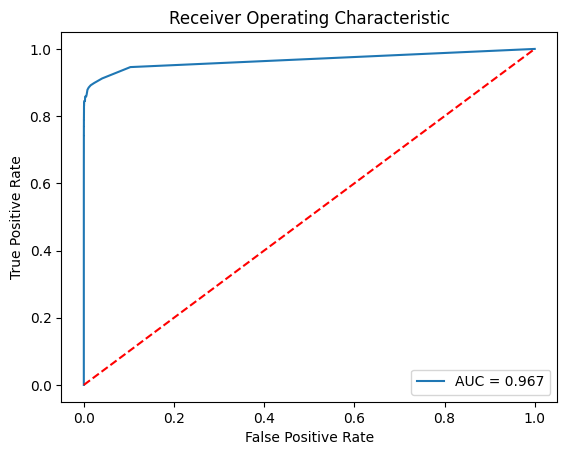

Accuracy: 0.9994148145547324
ROC AUC: 0.9668306972779686
Matriz de confusión:
 [[85276    19]
 [   31   117]]
Reporte de clasificación:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.86      0.79      0.82       148

    accuracy                           1.00     85443
   macro avg       0.93      0.90      0.91     85443
weighted avg       1.00      1.00      1.00     85443



In [20]:
clfRF = RandomForestClassifier(random_state=0)
clfRF.fit(X2_train_res, y2_train_res)

y2_pred_rf = clfRF.predict(X2_test)             
y2_prob_rf = clfRF.predict_proba(X2_test)[:,1]   

fpr, tpr, thresholds = roc_curve(y2_test, y2_prob_rf)
AUCRF = metrics.auc(fpr, tpr)

plt.figure()
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, label=f'AUC = {AUCRF:.3f}')
plt.plot([0,1], [0,1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

rep_RF = classification_report(y2_test, y2_pred_rf, output_dict=True)
recall_RF = rep_RF['1']['recall']
f1_RF = rep_RF['1']['f1-score']
precision_RF = rep_RF['1']['precision']
AUC_RF = roc_auc_score(y2_test, y2_prob_rf)
accuracy_RF = accuracy_score(y2_test, y2_pred_rf)


print("Accuracy:", accuracy_RF)
print("ROC AUC:", AUC_RF)
print("Matriz de confusión:\n", confusion_matrix(y2_test, y2_pred_rf))
print("Reporte de clasificación:\n", classification_report(y2_test, y2_pred_rf))


(Utilicen este espacio para describir su procedimiento y escribir su análisis y conclusiones sobre el punto 7)
#### Análisis y Conclusión punto 7

Inicialmente se realizó un balance de las clases de predicción mediante el método SMOTE. Este procedimiento se aplicó únicamente sobre el conjunto de entrenamiento con el fin de corregir el desbalance existente entre las clases.

Posteriormente, se implementó el método Random Forest con semilla 0 para garantizar la reproducibilidad de los resultados y utilizando los parámetros por defecto. Es importante resaltar que, a diferencia de otros métodos utilizados previamente, en este caso fue necesario entrenar el modelo con los datos balanceados para que el efecto del manejo del desbalance de clases se reflejara en el aprendizaje del modelo.

En cuanto a los resultados, se obtuvo un AUC de 0.95 y un accuracy de 0.99. Para la clase 1, que es la clase de interés, se obtuvo una precisión de 0.87, un recall de 0.80 y un F1-score de 0.83. Esto significa que el modelo identifica correctamente el 80 % de los verdaderos positivos, lo que indica una buena capacidad para detectar la clase minoritaria. La precisión de 0.87 señala que el 87 % de las predicciones positivas realizadas por el modelo son correctas, es decir, no genera un número elevado de falsas alarmas. Finalmente, el F1-score de 0.83 evidencia un buen equilibrio entre precisión y recall, permitiendo detectar casos positivos sin incrementar significativamente los errores de clasificación.

### 8. Elección del mejor modelo (10 puntos)
¿Cuál modelo de los dos modelos estimados (QDA sin balancear y random forest balanceando) en este caso resulta mejor para la predicción de la variable de respuesta en la segunda base de datos? Justifiquen su respuesta.

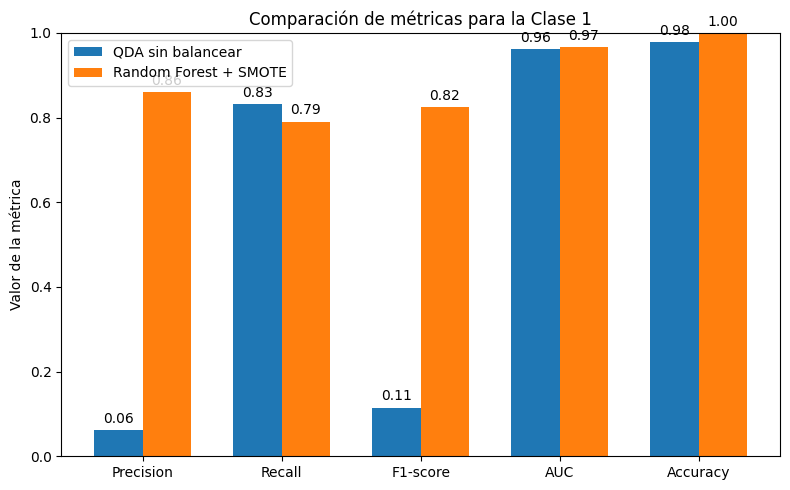

In [21]:
#### Utilicen este espacio para escribir los códigos del procedimiento del punto 8 ####

qda_metrics = [precision_qda, recall_qda, f1_qda, AUC_qda, accuracy_qda]
rf_metrics = [precision_RF, recall_RF, f1_RF, AUC_RF, accuracy_RF]

labels = ['Precision', 'Recall', 'F1-score', 'AUC', 'Accuracy']
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,5))

bars1 = plt.bar(x - width/2, qda_metrics, width, label='QDA sin balancear')
bars2 = plt.bar(x + width/2, rf_metrics, width, label='Random Forest + SMOTE')

plt.xticks(x, labels)
plt.ylim(0,1)
plt.ylabel('Valor de la métrica')
plt.title('Comparación de métricas para la Clase 1')
plt.legend()

for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 0.01,      
             f'{height:.2f}',
             ha='center', va='bottom')

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 0.01,
             f'{height:.2f}',
             ha='center', va='bottom')

plt.tight_layout()
plt.show()


(Utilicen este espacio para escribir su análisis y conclusiones sobre el punto 8)
#### Análisis y Conclusión punto 8

En la comparación podemos observar que el QDA tiene una precisión y un F1-score demasiado bajos, lo que indica que tendrá problemas para predecir correctamente la clase minoritaria, ya que la mayoría de las predicciones positivas serán incorrectas, generando muchos falsos positivos. Además, con el F1-score vemos que el promedio entre precision y recall es muy bajo, así que, a pesar de tener un recall alto y detectar muchos verdaderos positivos, muchos de estos serán incorrectos. Por lo tanto, es un modelo que no permite tener un buen desempeño en la clase 1 y no es recomendable utilizarlo en este contexto.

Finalmente, aunque presenta un AUC alto y un accuracy alto, estas métricas pueden no ser muy confiables en este caso, ya que al tratarse de una clase desbalanceada pueden estar dominadas por la clase mayoritaria. Por lo tanto, no reflejan correctamente la capacidad real del modelo para predecir la clase minoritaria.

Por otra parte, en el modelo Random Forest con uso de la metodología SMOTE para balancear las clases, podemos observar que, aunque el recall baja ligeramente (0.02), se obtiene una mejora sustancial en la precision (de 0.06 a 0.87) y en el F1-score (de 0.11 a 0.84). En este sentido, se logra un equilibrio mucho más adecuado entre precision y recall, obteniendo un F1-score alto en comparación con el bajo desempeño anterior. Este modelo generará muchas menos falsas alarmas que el QDA, dado que aumenta significativamente la precision.

En cuanto al AUC y el accuracy, ambos modelos presentan valores cercanos. Sin embargo, como se mencionó anteriormente, estas métricas no se utilizarán como criterio principal de comparación debido al desbalance de clases, ya que pueden estar sesgadas por la clase mayoritaria. Por lo tanto, se priorizan las métricas específicas de la clase 1, que es la clase de interés en este problema.

En conclusión, el mejor modelo es Random Forest con el uso de SMOTE para generar datos sintéticos en la clase minoritaria. Esto se evidencia en el aumento significativo de la precision y del F1-score en la clase 1, lo cual mejora considerablemente la capacidad predictiva y hace que el modelo sea más confiable.

Además, desde el punto de vista algorítmico, Random Forest es superior a QDA en este contexto. QDA asume una distribución normal en cada clase y estima matrices de covarianza, lo cual puede verse afectado cuando existe un fuerte desbalance de clases. En cambio, Random Forest no impone supuestos distribucionales, captura relaciones no lineales mediante múltiples árboles de decisión y reduce la varianza al promediar sus resultados. Por ello, tanto empíricamente como teóricamente, el modelo más adecuado es Random Forest con balanceo mediante SMOTE.